In [ ]:
from ml_enhance import StatisticalComparison, plot_FI
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any
import pandas as pd
import numpy as np
import pickle
import json

## Huber Regression: Topology VS. QM + Topology

As the data (even after transformation and scaling) consists of a lot of outliers that cannot be removed (as they are valid molecules and are therefore part of the real world observables) I decided to use [Huber regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) instead of linear regression, this method is more robust to outliers.

In [9]:
def get_coef(estimator) -> np.ndarray:
    return estimator.named_steps['predict'].coef_

In [ ]:
BASE = Path("../data/HuberReg_results")

with open(BASE / "HuberReg_combo2.pkl", "rb") as f:
    scores_combo = pickle.load(f)

with open(BASE / "HuberReg_topo.pkl", "rb") as f:
    scores_topo = pickle.load(f)

with open(BASE / "HuberReg_qm2.pkl", "rb") as f:
    scores_qm = pickle.load(f)

with open(BASE / "HuberReg_combo_pure.pkl", "rb") as f:
    scores_combo_pure = pickle.load(f)

with open(BASE / "HuberReg_combo_pure2.pkl", "rb") as f:
    scores_combo_pure2 = pickle.load(f)

with open(BASE / "HuberReg_topo_pure.pkl", "rb") as f:
    scores_topo_pure = pickle.load(f)

with open(BASE / "HuberReg_qm_pure2.pkl", "rb") as f:
    scores_qm_pure2 = pickle.load(f)

# with open("../3-RFE/HuberReg_RFE_combo.pkl", "rb") as f:
#     scores_combo_rfe = pickle.load(f)

# with open("../3-RFE/HuberReg_RFE_combo_filtered.pkl", "rb") as f:
#     scores_combo_pure_rfe = pickle.load(f)

In [11]:
n_tot = X.shape[0]
n_train = n_tot * 4 // 5  
n_test = n_tot - n_train

In [12]:
def compare(scores_combo: dict[str, Any], scores_topo: dict[str, Any], scores_qm: dict[str, Any], metric: str, n_train: int=n_train, n_test: int=n_test):
    topo_scores = scores_topo[f"test_{metric}"]
    combo_scores = scores_combo[f"test_{metric}"]

    comparator = StatisticalComparison(combo_scores, topo_scores)
    ttest_result =  comparator.nadeau_bengio_corrected_t_test(n_train, n_test)
    wilcoxon_result = comparator.wilcoxon_fold_differences()

    print(f"Topo mean {metric}: {np.abs(topo_scores).mean()} (Train: {np.abs(scores_topo[f"train_{metric}"]).mean()})")
    print(f"QM mean {metric}: {np.abs(scores_qm[f"test_{metric}"]).mean()} (Train: {np.abs(scores_qm[f"train_{metric}"]).mean()})")
    print(f"Combined mean {metric}: {np.abs(combo_scores).mean()} (Train: {np.abs(scores_combo[f"train_{metric}"]).mean()})")
    print("Mean improvement:", ttest_result["mean_diff"])
    print("\n")
    print(f"T-test p-value: {ttest_result["p_value"]} ->{' not' if ttest_result["p_value"] > 0.05 else ''} statistically significant")
    print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{' not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

In [13]:
compare(scores_combo, scores_topo, scores_qm, "r2")
print("\n\n")
compare(scores_combo, scores_topo, scores_qm, "MSE")
print("\n\n")
compare(scores_combo_pure2, scores_topo_pure, scores_qm_pure2, metric="r2")
print("\n\n")
compare(scores_combo_pure2, scores_topo_pure, scores_qm_pure2, metric="MSE")
print("\n\n")
compare(scores_combo_pure2, scores_topo, scores_qm_pure2, metric="r2")

Topo mean r2: 0.8165431744783785 (Train: 0.828593460790121)
QM mean r2: 0.7675028269739056 (Train: 0.7785832858086404)
Combined mean r2: 0.8182921649446872 (Train: 0.8459617045379271)
Mean improvement: 0.001748990466308582


T-test p-value: 0.7344449709451584 -> not statistically significant
Wilcoxon p-value: 0.6338268518447876 -> not statistically significant



Topo mean MSE: 0.9761522026122949 (Train: 0.9129057702165864)
QM mean MSE: 1.237016140641999 (Train: 1.1792329835729303)
Combined mean MSE: 0.9668244918957462 (Train: 0.8203890583144474)
Mean improvement: -0.009327710716548704


T-test p-value: 0.7226497931819518 -> not statistically significant
Wilcoxon p-value: 0.3665854334831238 -> not statistically significant



Topo mean r2: 0.8161804537353434 (Train: 0.8279539473729882)
QM mean r2: 0.7411990465587013 (Train: 0.7582517461419046)
Combined mean r2: 0.8247512893419073 (Train: 0.8436066597273018)
Mean improvement: 0.008570835606563923


T-test p-value: 0.08463520848719441 ->

In [19]:
topo_r2s = np.abs(scores_topo["test_r2"])
topo_filtered_r2s = np.abs(scores_topo_pure["test_r2"])
combo_r2s = scores_combo["test_r2"]
combo_filtered_r2s = scores_combo_pure2["test_r2"]
# combo_filtered_rfe_r2s = scores_combo_pure_rfe["test_r2"]
# combo_rfe_r2s = scores_combo_rfe["test_r2"]

r2s = np.array([topo_r2s, topo_filtered_r2s, combo_r2s, combo_filtered_r2s])
names = ["topo", "topo_filtered", "topo+QM", "topo+QM_filtered"]
r2_df = pd.DataFrame(r2s.T, columns=names)

In [23]:
r2_df_long = r2_df.melt(var_name="model", value_name="r2")

C:\Users\thibo\AppData\Local\Temp\ipykernel_5460\3350912808.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


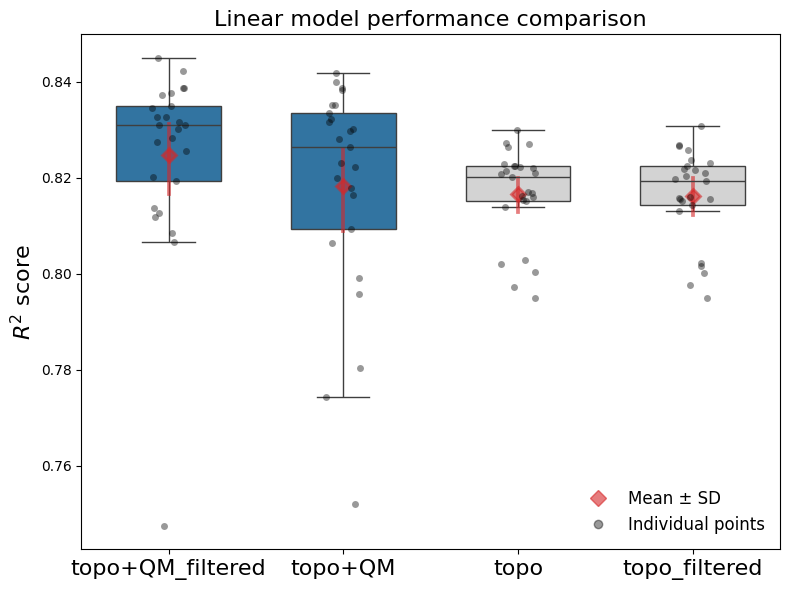

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

order = (
    r2_df_long.groupby("model")["r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

blue_models = ["topo+QM", "topo+QM_rfe", "topo+QM_filtered", "topo+QM_filtered_rfe"]

palette = {
    model: "tab:blue" if model in blue_models else "lightgray"
    for model in r2_df.columns
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df_long,
    x="model",
    y="r2",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df_long,
    x="model",
    y="r2",
    order=order,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df_long, x="model", y="r2", color="black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    # Patch(facecolor="tab:blue", edgecolor="black", label="QM + topo"),
    # Patch(facecolor="lightgray", edgecolor="black", label="Topo-only"),
    Patch(facecolor="tab:red", edgecolor="black", label="Mean ± SD"),
    Patch(facecolor="black", edgecolor="black", label="Individual points", alpha=0.4)
]

plt.legend(handles=[point_handle, strip_handle], loc="lower right", frameon=False, fontsize=12)

plt.xticks(fontsize=16)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Linear model performance comparison", fontsize=16)
# plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

Based on the results i got from the Huber regression, the QM descriptors alone seem to give the worst performance out of the three and **there seems to be no significant difference between the topological descriptors alone and the combined feature set**. 

<!-- The combined set of features provides a slightly better prediction. Whether this is truely because of the QM descriptors, or because of model bias should be analyzed by looking at other models (RF, GAM, KRR?) -->

In [25]:
from collections import Counter

all_params = [estimator.best_params_ for estimator in scores_combo["estimator"]]

count = Counter(tuple(p.items()) for p in all_params)
most_common = count.most_common(1)
best_params = dict(most_common[0][0])
best_params

{'predict__alpha': 0.01, 'predict__epsilon': 2.0}

In [26]:
def get_FI(estimator) -> pd.Series:
    FI = dict(zip(estimator.best_estimator_[:-1].get_feature_names_out(), estimator.best_estimator_[-1].coef_))
    return pd.Series(FI)

In [32]:
best_combo_idx = scores_combo["test_r2"].argmax()
best_combo = scores_combo["estimator"][best_combo_idx]
combo_FI = get_FI(best_combo)

best_combo_filtered_idx = scores_combo_pure2["test_r2"].argmax()
best_combo_filtered = scores_combo_pure2["estimator"][best_combo_filtered_idx]
combo_filtered_FI = get_FI(best_combo_filtered)

# best_topo_idx = scores_topo["test_r2"].argmax()
# best_topo = scores_topo["estimator"][best_topo_idx]
# keys_topo, values_topo = get_FI(best_topo)

best_qm_idx = scores_qm_pure2["test_r2"].argmax()
best_qm = scores_qm_pure2["estimator"][best_qm_idx]
qm_filtered_FI = get_FI(best_qm)

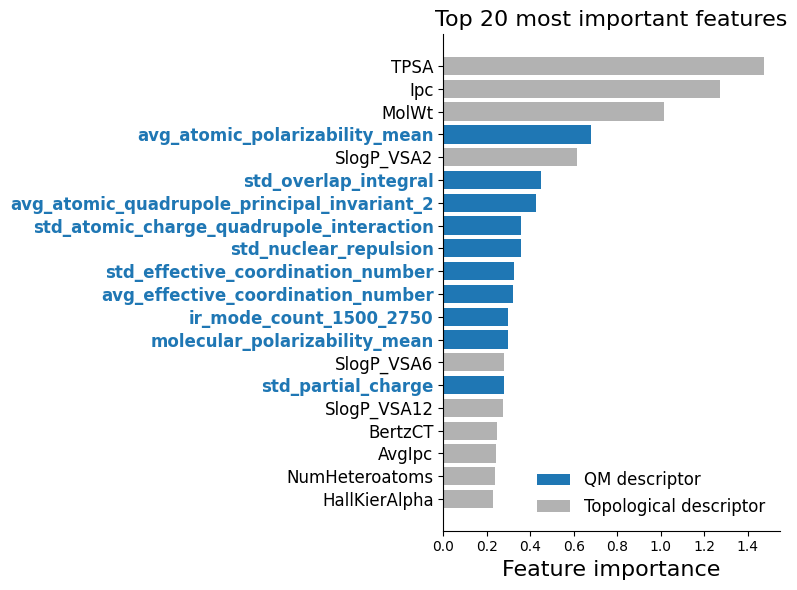

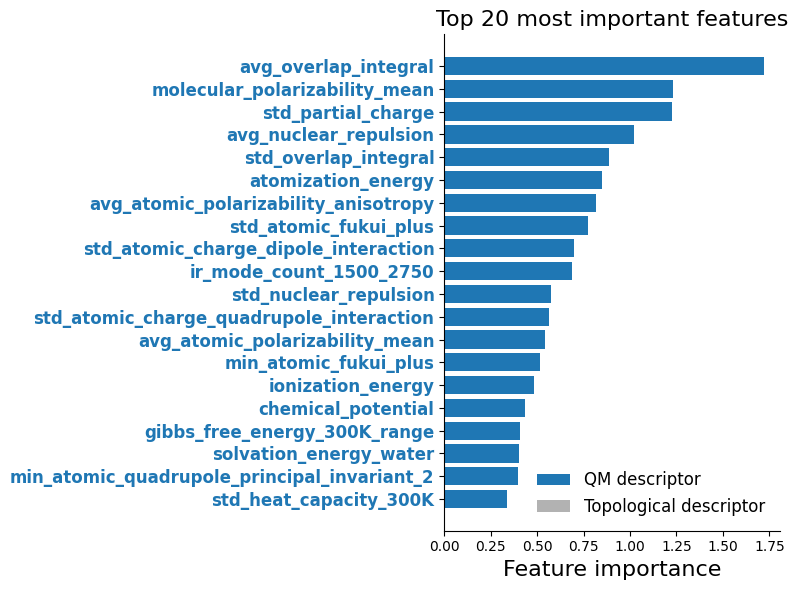

In [33]:
plot_FI(combo_filtered_FI, 20)
plot_FI(qm_filtered_FI, 20)

In [ ]:
def get_FI_rfe(estimator, how_many=20):
    FI = dict(zip(estimator.get_feature_names_out(), estimator.estimator_.named_steps["predict"].coef_))
    return pd.Series(FI)

I want to try some feature combinations with the QFP features purely focussing on the quantum features, and leaving out the topology based features.

So, after removing the topological features from the QFP feature set, it seems like a lot of QM features have gained more importance for the Topology + QM feature set